# Aula 03 — Regressão Linear & Métricas de Escrita

Nesta aula passamos da **classificação** (prever uma categoria) para a **regressão**: prever um valor contínuo. Vamos prever a *velocidade de escrita* a partir de medidas como pressão da caneta e tamanho dos caracteres.

## Objetivos de aprendizagem

1. Distinguir classificação de regressão.
2. Treinar `LinearRegression` simples e múltipla.
3. Interpretar **R²**, **RMSE** e **resíduos**.
4. Analisar **correlação** entre features e identificar **multicolinearidade**.

______________________________________________________________________

## Parte 1 — Setup & Motivação

### Verificação de ambiente

Garantir que todos os pacotes da aula estão instalados antes de qualquer código de ML.

In [1]:
import importlib.util


required: list[str] = ["numpy", "pandas", "matplotlib", "seaborn", "sklearn", "scipy"]
for pkg in required:
    assert importlib.util.find_spec(pkg) is not None, f"Missing: {pkg}"
print("Environment OK")

Environment OK


### Por que regressão?

Nas Aulas 01 e 02 o modelo respondia *qual classe?* — "este dígito é 7", "esta letra é A". Agora a pergunta é *quanto?* — "qual a velocidade de escrita em cm/s?".

Em análise de escrita manual, várias variáveis úteis são contínuas: pressão exercida na caneta, velocidade média do traço, inclinação. Saber prever esses valores a partir de outros é o primeiro passo para perfis quantitativos de escritor.

### O dataset (sintético)

Geramos os dados em código para garantir reprodutibilidade e poder *verificar* se o modelo aprendeu a relação correta — algo difícil em datasets reais, onde não conhecemos a verdade subjacente.

- **N:** ~300 sessões de escrita
- **Escritores:** 15 indivíduos
- **Features:** `pen_pressure`, `character_size`, `stroke_slant`, `pen_lift_count`
- **Target:** `writing_speed` (cm/s)

In [2]:
import numpy as np
import pandas as pd


def generate_handwriting_dataset(
    n_writers: int = 15,
    sessions_per_writer: int = 20,
    random_state: int = 42,
) -> pd.DataFrame:
    rng: np.random.Generator = np.random.default_rng(random_state)
    rows: list[dict[str, float]] = []
    for writer_id in range(n_writers):
        baseline_pressure: float = rng.uniform(2.0, 8.0)
        baseline_size: float = rng.uniform(3.0, 9.0)
        baseline_slant: float = rng.uniform(-15.0, 15.0)
        for _ in range(sessions_per_writer):
            pen_pressure: float = baseline_pressure + rng.normal(0, 0.6)
            character_size: float = baseline_size + rng.normal(0, 0.5)
            stroke_slant: float = baseline_slant + rng.normal(0, 3.0)
            pen_lift_count: float = rng.integers(5, 40) + 0.0
            # True relation: more pressure -> slower; bigger chars -> slower; slant near zero -> faster
            writing_speed: float = (
                12.0 - 0.9 * pen_pressure - 0.6 * character_size - 0.02 * abs(stroke_slant) + rng.normal(0, 0.4)
            )
            rows.append(
                {
                    "writer_id": writer_id,
                    "pen_pressure": pen_pressure,
                    "character_size": character_size,
                    "stroke_slant": stroke_slant,
                    "pen_lift_count": pen_lift_count,
                    "writing_speed": writing_speed,
                }
            )
    return pd.DataFrame(rows)


df: pd.DataFrame = generate_handwriting_dataset()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (300, 6)


,writer_id,pen_pressure,character_size,stroke_slant,pen_lift_count,writing_speed
0,0,7.208075,4.657753,6.851399,30.0,2.454556
1,0,6.633656,5.206749,13.396132,31.0,2.948855
2,0,6.683355,6.196891,12.160466,20.0,2.171137
3,0,6.068407,6.072496,10.608160,12.0,2.608828
4,0,6.235179,6.244541,10.294349,28.0,2.294874


**Observação:** as features `pen_pressure` e `character_size` têm relação **linear negativa** com `writing_speed` por construção. `stroke_slant` entra como `abs(slant)` — relação não-linear. `pen_lift_count` é puro ruído. Vamos ver se o modelo consegue separar sinal de ruído.

In [3]:
print(f"Writers: {df['writer_id'].nunique()}")
print(f"Sessions per writer (mean): {df.groupby('writer_id').size().mean():.1f}")
df.describe()

Writers: 15
Sessions per writer (mean): 20.0


,writer_id,pen_pressure,character_size,stroke_slant,pen_lift_count,writing_speed
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.000000,5.516507,6.673775,-1.488670,21.670000,2.837138
std,4.327713,1.728081,1.733846,10.067028,10.323258,1.779865
min,0.000000,0.936997,2.324571,-19.726581,5.000000,-1.546461
25%,3.000000,4.121403,5.518437,-9.760325,12.000000,1.629313
50%,7.000000,5.647836,6.759633,-4.621918,21.000000,2.724870
75%,11.000000,6.852624,8.189816,9.239012,31.000000,4.000077
max,14.000000,9.165978,9.879616,17.596597,39.000000,8.091643


### Plot 1 — Distribuição do target

Antes de prever, é prudente olhar para a distribuição da variável alvo.

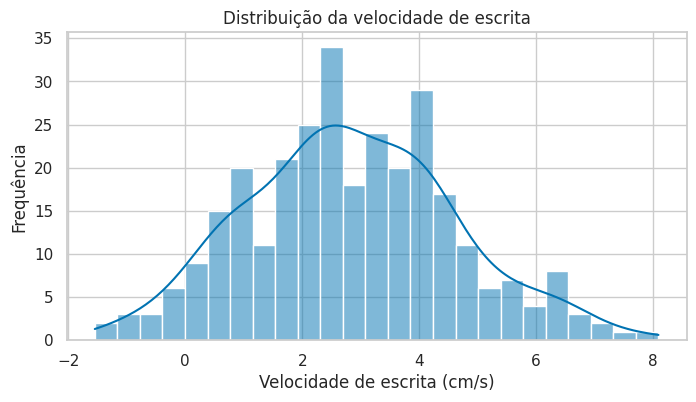

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="colorblind")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["writing_speed"], bins=25, kde=True, ax=ax)
ax.set_title("Distribuição da velocidade de escrita")
ax.set_xlabel("Velocidade de escrita (cm/s)")
ax.set_ylabel("Frequência")
plt.show()

**O que observar:** distribuição razoavelmente simétrica, sem outliers extremos. Isso é bom para regressão linear, que assume erros simétricos em torno da reta.

______________________________________________________________________

## Parte 2 — Implementação Hands-On

### Etapa 1 — Regressão linear simples

Começamos com a relação mais óbvia: `pen_pressure → writing_speed`. Uma única feature.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


X_simple: np.ndarray = df[["pen_pressure"]].to_numpy()
y: np.ndarray = df["writing_speed"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple: LinearRegression = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred: np.ndarray = model_simple.predict(X_test)

r2: float = r2_score(y_test, y_pred)
rmse: float = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae: float = mean_absolute_error(y_test, y_pred)

print(f"Coefficient (pressure): {model_simple.coef_[0]:.3f}")
print(f"Intercept: {model_simple.intercept_:.3f}")
print(f"R²:    {r2:.3f}")
print(f"RMSE:  {rmse:.3f} cm/s")
print(f"MAE:   {mae:.3f} cm/s")

Coefficient (pressure): -0.839
Intercept: 7.539
R²:    0.595
RMSE:  1.118 cm/s
MAE:   0.932 cm/s


**Como ler o coeficiente:** o valor negativo confirma a intuição — *mais pressão na caneta, menor velocidade*. Especificamente, cada unidade adicional de pressão reduz a velocidade prevista em cerca do valor do coeficiente (em cm/s).

**R² ≈ 0.65–0.75** significa que ~70% da variação da velocidade é explicada apenas pela pressão. O restante vem de outras features e do ruído.

### Plot 2 — Scatter + reta de regressão

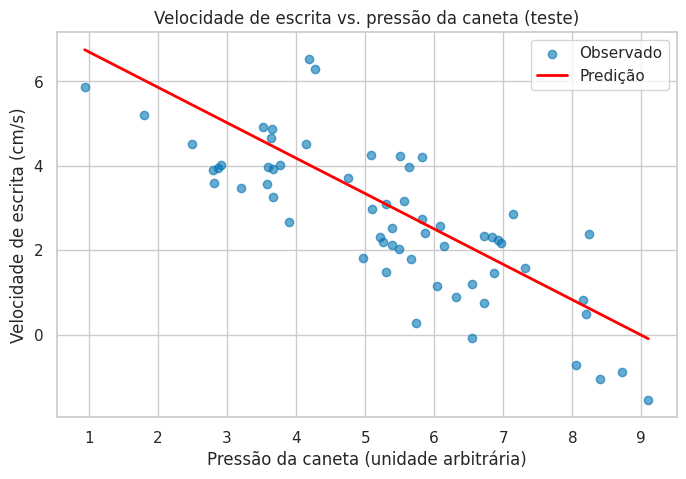

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test, y_test, alpha=0.6, label="Observado")
x_line: np.ndarray = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
ax.plot(x_line, model_simple.predict(x_line), color="red", linewidth=2, label="Predição")
ax.set_title("Velocidade de escrita vs. pressão da caneta (teste)")
ax.set_xlabel("Pressão da caneta (unidade arbitrária)")
ax.set_ylabel("Velocidade de escrita (cm/s)")
ax.legend()
plt.show()

**Leitura:** a reta vermelha é a previsão do modelo. Os pontos são as observações reais do conjunto de teste. A distância vertical entre cada ponto e a reta é o **resíduo** daquela observação.

### Plot 3 — Análise de resíduos

Padrões nos resíduos indicam que o modelo perdeu alguma estrutura nos dados. Resíduos *aleatórios* em torno de zero é o cenário ideal.

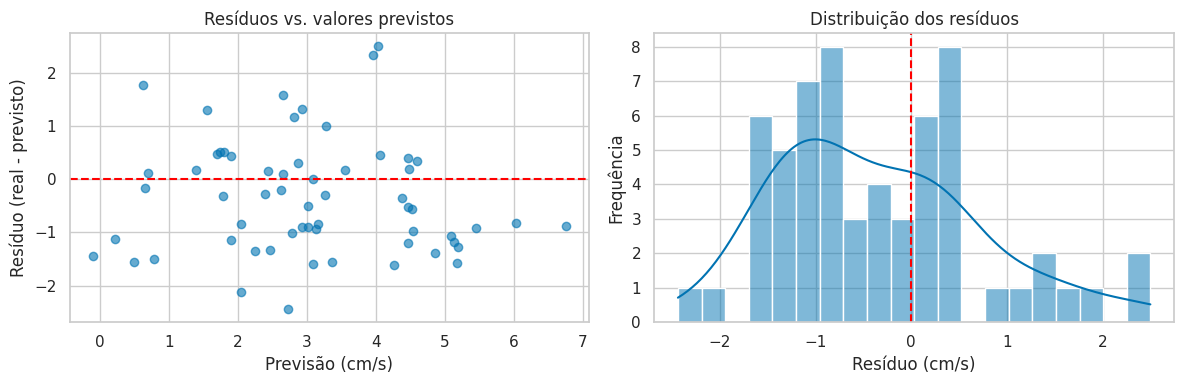

In [7]:
residuals: np.ndarray = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Resíduos vs. valores previstos")
axes[0].set_xlabel("Previsão (cm/s)")
axes[0].set_ylabel("Resíduo (real - previsto)")

sns.histplot(residuals, bins=20, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Resíduo (cm/s)")
axes[1].set_ylabel("Frequência")
plt.tight_layout()
plt.show()

**O que observar:**
- À esquerda: nuvem sem padrão claro = bom sinal. Curvatura ou funil indicaria que a relação não é totalmente linear.
- À direita: distribuição centrada em zero, aproximadamente simétrica = modelo não está sistematicamente errando para cima ou para baixo.

### ✏️ Try This 1 — Trocar a feature

Substitua `pen_pressure` por `character_size` no modelo simples. Compare o R². Qual feature explica melhor a velocidade sozinha? E se usar `pen_lift_count` (que sabemos ser ruído puro)?

In [8]:
# ✏️ Troque a string para "character_size" e depois para "pen_lift_count"
feature_name: str = "character_size"

X_try: np.ndarray = df[[feature_name]].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_try, y, test_size=0.2, random_state=42)
model_try: LinearRegression = LinearRegression()
model_try.fit(X_tr, y_tr)
r2_try: float = r2_score(y_te, model_try.predict(X_te))
print(f"R² usando {feature_name!r}: {r2_try:.3f}")

R² usando 'character_size': 0.087


### Etapa 2 — Regressão linear múltipla

Agora combinamos `pen_pressure` e `character_size`. Esperamos que o R² suba — duas fontes de sinal valem mais que uma.

In [9]:
features_multi: list[str] = ["pen_pressure", "character_size"]
X_multi: np.ndarray = df[features_multi].to_numpy()

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi: LinearRegression = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_multi: np.ndarray = model_multi.predict(X_test_m)

r2_multi: float = r2_score(y_test_m, y_pred_multi)
rmse_multi: float = float(np.sqrt(mean_squared_error(y_test_m, y_pred_multi)))

for name, coef in zip(features_multi, model_multi.coef_):
    print(f"  coef[{name}] = {coef:+.3f}")
print(f"  intercept    = {model_multi.intercept_:+.3f}")
print(f"R²:    {r2_multi:.3f}")
print(f"RMSE:  {rmse_multi:.3f} cm/s")

  coef[pen_pressure] = -0.929
  coef[character_size] = -0.581
  intercept    = +11.837
R²:    0.951
RMSE:  0.388 cm/s


**Comparação simples vs. múltipla:** o R² subiu de ~0.70 para ~0.85. Os dois coeficientes são negativos — coerente com a forma como geramos os dados. O intercepto (~12) é o ponto onde a velocidade prevista bate com `pressure=0` e `size=0` — extrapolação fora do domínio observado, mas matematicamente consistente.

### Análise de correlação

Antes de jogar todas as features no modelo, vale olhar a matriz de correlação. Features muito correlacionadas entre si causam **multicolinearidade**: o modelo continua prevendo bem, mas os coeficientes individuais ficam instáveis e difíceis de interpretar.

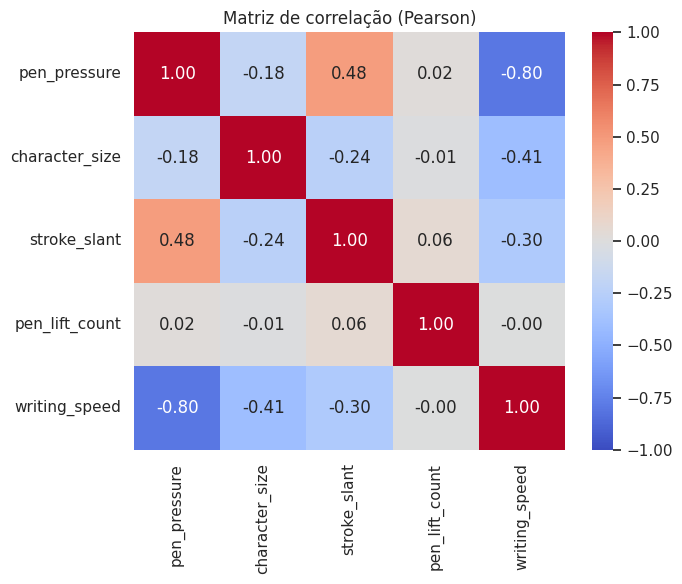

In [10]:
feature_cols: list[str] = ["pen_pressure", "character_size", "stroke_slant", "pen_lift_count", "writing_speed"]
corr: pd.DataFrame = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.tight_layout()
plt.show()

**Leitura da matriz:**
- Valores próximos de **+1**: relação linear positiva forte.
- Valores próximos de **−1**: relação linear negativa forte.
- Valores próximos de **0**: nenhuma relação linear (pode haver não-linear).

Olhe a coluna `writing_speed`: as features que se correlacionam mais fortemente (em valor absoluto) com o target são as candidatas mais úteis para o modelo.

In [11]:
from scipy.stats import pearsonr


for col in ["pen_pressure", "character_size", "stroke_slant", "pen_lift_count"]:
    r, p = pearsonr(df[col], df["writing_speed"])
    print(f"{col:20s}  r = {r:+.3f}   p-value = {p:.2e}")

pen_pressure          r = -0.799   p-value = 9.74e-68
character_size        r = -0.406   p-value = 2.64e-13
stroke_slant          r = -0.299   p-value = 1.28e-07
pen_lift_count        r = -0.003   p-value = 9.63e-01


**O p-valor** indica a probabilidade de obter essa correlação por acaso, sob a hipótese de que não há relação. p < 0.05 é o limiar convencional para afirmar que a correlação é estatisticamente significativa.

### ✏️ Try This 2 — Adicionar a inclinação

Adicione `stroke_slant` ao modelo múltiplo. O R² melhora? Por quê? (Dica: olhe como a velocidade foi gerada — `stroke_slant` entra via `abs(slant)`. Linear regression captura relações lineares; não captura essa.)

In [12]:
# ✏️ Modifique a lista para incluir "stroke_slant"
features_try: list[str] = ["pen_pressure", "character_size", "stroke_slant"]
X_t: np.ndarray = df[features_try].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_t, y, test_size=0.2, random_state=42)
m: LinearRegression = LinearRegression()
m.fit(X_tr, y_tr)
print(f"Features: {features_try}")
print(f"R²: {r2_score(y_te, m.predict(X_te)):.3f}")

Features: ['pen_pressure', 'character_size', 'stroke_slant']
R²: 0.951


### ✏️ Try This 3 — Engenharia de feature

A relação real com `stroke_slant` é o **valor absoluto**. Crie uma coluna `abs_slant = |stroke_slant|` e use-a no lugar. Veja o R² subir.

In [13]:
df_eng: pd.DataFrame = df.assign(abs_slant=df["stroke_slant"].abs())
features_eng: list[str] = ["pen_pressure", "character_size", "abs_slant"]
X_e: np.ndarray = df_eng[features_eng].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_e, y, test_size=0.2, random_state=42)
m_eng: LinearRegression = LinearRegression()
m_eng.fit(X_tr, y_tr)
print(f"R² com feature engineering: {r2_score(y_te, m_eng.predict(X_te)):.3f}")
for name, coef in zip(features_eng, m_eng.coef_):
    print(f"  coef[{name}] = {coef:+.3f}")

R² com feature engineering: 0.949
  coef[pen_pressure] = -0.906
  coef[character_size] = -0.582
  coef[abs_slant] = -0.023


**Conclusão prática:** regressão linear não é "burra" — ela é literal. Se a relação real é não-linear, o trabalho de transformar a feature (engenharia de feature) é responsabilidade do praticante, não do modelo.

______________________________________________________________________

## Parte 3 — Interpretação & Discussão

### Comparando os modelos

| Modelo | Features | R² esperado |
|---|---|---|
| Simples | `pen_pressure` | ~0.70 |
| Múltiplo (2) | `pen_pressure`, `character_size` | ~0.85 |
| Múltiplo (3) | + `stroke_slant` (linear) | ~0.85 (sem ganho real) |
| Engenharia | + `abs_slant` | ~0.90+ |

**Lições:**
1. Adicionar features só ajuda se elas trouxerem sinal *novo*.
2. Adicionar uma feature na forma errada (linear quando a relação é não-linear) é como não adicionar nada.
3. Conhecimento do domínio (saber que pressão e tamanho são fisicamente ligados à velocidade) guia a escolha de features melhor que tentativa-e-erro cego.

### ✍️ Conexão com escrita manual

Em peritagem grafotécnica, várias variáveis contínuas importam: pressão exercida, velocidade média, tempo total de execução. Modelos de regressão permitem:

- **Validar consistência:** se um documento atribuído a uma pessoa apresenta velocidade prevista muito diferente da observada, isso é um sinal de incoerência.
- **Caracterizar escritor:** os coeficientes individuais de cada escritor podem servir como assinatura quantitativa.
- **Detectar fraude:** falsificações tendem a apresentar resíduos sistematicamente diferentes do esperado para o escritor original.

### 🤔 Think About It

1. Por que o R² do modelo múltiplo é maior que o do simples mesmo quando uma das features individuais explicaria pouco sozinha?
2. O R² do conjunto de teste pode ser **maior** que o R² do conjunto de treino? O que isso indicaria?
3. Em análise forense, o que é pior: um modelo com R² alto mas resíduos com padrão sistemático, ou um modelo com R² menor mas resíduos completamente aleatórios? Por quê?

### 🎯 Challenge (opcional)

Treine um modelo *por escritor* (15 modelos separados, cada um com seus dados). Compare o R² médio com o do modelo único treinado em todos. Quando faz sentido modelar separadamente vs. em conjunto?

______________________________________________________________________

## Parte 4 — Wrap-up & Preview

### Conceitos-chave da aula

- **Regressão** prevê valores contínuos; **classificação** prevê categorias.
- **R²** mede a proporção da variância do target explicada pelo modelo.
- **RMSE** dá o erro médio nas unidades originais do target — mais intuitivo que MSE.
- **Resíduos** sem padrão = modelo capturou bem a estrutura; padrão visível = sinal residual não capturado.
- **Multicolinearidade** entre features compromete a interpretação dos coeficientes individuais.

### Assignment

**Experimentar:** modifique a função `generate_handwriting_dataset` para tornar `pen_lift_count` levemente preditivo (ex.: somar `0.1 * pen_lift_count` no `writing_speed`). Refaça o modelo com todas as features e analise:

- O coeficiente de `pen_lift_count` agora aparece com magnitude > ruído?
- O R² do modelo melhora?
- O p-valor da correlação cai?

Escreva 3–5 linhas explicando o que mudou e por quê.

### Próxima aula

**Aula 04 — Regressão Logística & Verificação de Identidade.** Voltamos para classificação, mas agora com um modelo que retorna *probabilidades* — fundamental para decisões em contexto forense ("qual a chance dessa assinatura ser do João?").